# Matplotlib

#### Week 1 - Day 5

This notebook covers 4 basic Python exercises:

1. **Loading and cleaning** a provided **dataset** with Pandas (handling any missing values).
2. **Using NumPy** to compute at least one derived numeric feature or summary statistic.
3. Producing at least three labeled plots (including a **histogram** and a **scatter plot**) exploring the data.
4. **Writing Markdown cells** explaining what each **visualization** reveals about the data.

> Note: Words written in bold represents key topics that were studied and covered during the day.

> **Note: I will use the same previous dataset - UCI Adult Census Income -.**

## Exercise 1

In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/adult.csv")

df.replace("?",  np.nan, inplace=True)   # replacing "?" with "NaN" to detect missing values.

for col in ["workclass", "occupation", "native.country"]:  # Fill missing values in categorical columns with the most frequent (mode()).
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Shape:", df.shape)
print("Remaining Missing Values:", df.isnull().sum())
df.head()

Shape: (32561, 15)
Remaining Missing Values: age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Exercise 2

In [33]:
age_array = df["age"].values

min_age = age_array.min()
max_age = age_array.max()

df["age_normalized"] = (age_array - min_age) / (max_age - min_age)  # Scale age values to a range between 0 & 1

print(df[["age", "age_normalized"]].head())

   age  age_normalized
0   90        1.000000
1   82        0.890411
2   66        0.671233
3   54        0.506849
4   41        0.328767


## Exercise 3

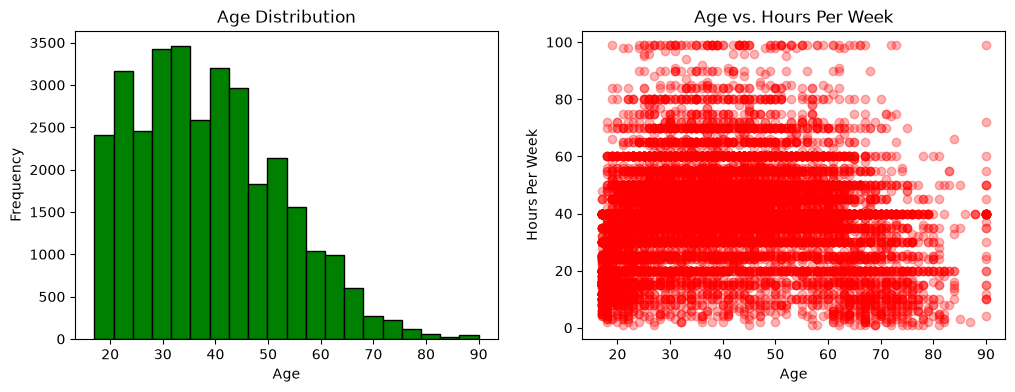

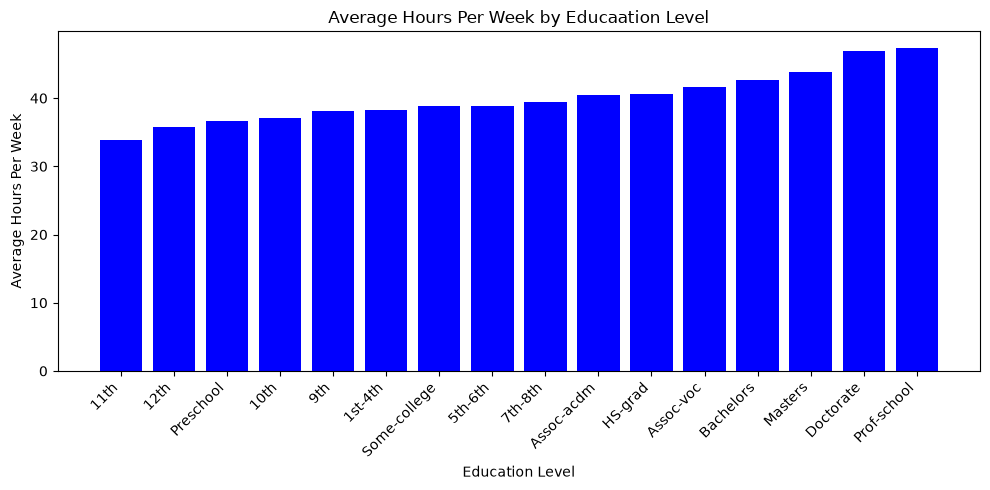

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))   # Create a figure with 1 row & 2 columns and it is (side by side).

# Histogram of Age distribution:
axes[0].hist(df["age"], bins=20, color="green", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Scatter plot of Age vs. hours-per-week:
axes[1].scatter(df["age"], df["hours.per.week"], alpha=0.3, color="red")
axes[1].set_title("Age vs. Hours Per Week")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Hours Per Week")

# Bar chart of Hours Per Week by education level:
avg_hours = df.groupby("education")["hours.per.week"].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
plt.bar(avg_hours.index, avg_hours.values, color="blue")
plt.title("Average Hours Per Week by Educaation Level")
plt.xlabel("Education Level")
plt.ylabel("Average Hours Per Week")
plt.xticks(rotation=45, ha="right")   # rotate the x_axis labels to prevents overlapping.

plt.tight_layout()         # tight_layout(): prevents titles and labels from overlapping between two plots.
plt.show()

>**Each of the above exercises are explained by Markdown cell or by the commentes.**